# K-Means Clustering Exercise
Data from the US Government about countries.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../../jupyter_notebooks/DATA/CIA_Country_Facts.csv')

In [3]:
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    str    
 1   Region                              227 non-null    str    
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-null    floa

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Population,227.0,2.874028e+07,1.178913e+08,7026.000,437624.00000,4786994.000,1.749777e+07,1.313974e+09
Area (sq. mi.),227.0,5.982270e+05,1.790282e+06,2.000,4647.50000,86600.000,4.418110e+05,1.707520e+07
Pop. Density (per sq. mi.),227.0,3.790471e+02,1.660186e+03,0.000,29.15000,78.800,1.901500e+02,1.627150e+04
Coastline (coast/area ratio),227.0,2.116533e+01,7.228686e+01,0.000,0.10000,0.730,1.034500e+01,8.706600e+02
Net migration,224.0,3.812500e-02,4.889269e+00,-20.990,-0.92750,0.000,9.975000e-01,2.306000e+01
Infant mortality (per 1000 births),224.0,3.550696e+01,3.538990e+01,2.290,8.15000,21.000,5.570500e+01,1.911900e+02
GDP ($ per capita),226.0,9.689823e+03,1.004914e+04,500.000,1900.00000,5550.000,1.570000e+04,5.510000e+04
Literacy (%),209.0,8.283828e+01,1.972217e+01,17.600,70.60000,92.500,9.800000e+01,1.000000e+02
Phones (per 1000),223.0,2.360614e+02,2.279918e+02,0.200,37.80000,176.200,3.896500e+02,1.035600e+03
Arable (%),225.0,1.379711e+01,1.304040e+01,0.000,3.22000,10.420,2.000000e+01,6.211000e+01


Text(0.5, 1.0, 'Population histogram (log scale)')

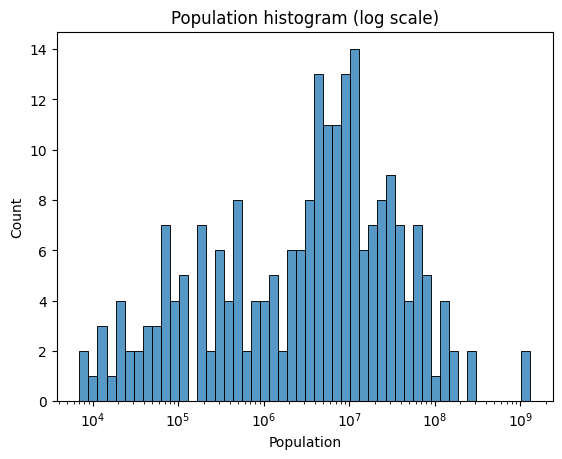

In [6]:
sns.histplot(data=df,x='Population',bins=50,log_scale=True)
plt.title('Population histogram (log scale)')

(0.0, 25.0)

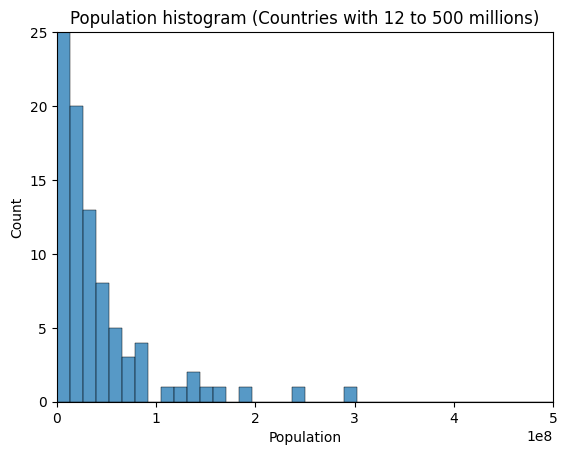

In [7]:
sns.histplot(data=df,x='Population',bins=100)
plt.title('Population histogram (Countries with 12 to 500 millions)')
plt.xlim(0,500000000)
plt.ylim(0,25)

(0.0, 25.0)

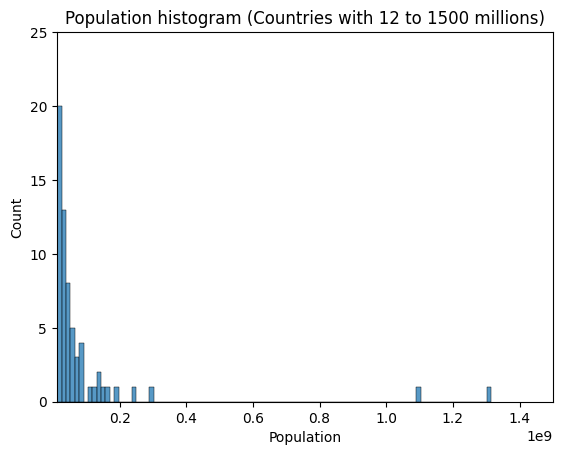

In [8]:
sns.histplot(data=df,x='Population',bins=100)
plt.title('Population histogram (Countries with 12 to 1500 millions)')
plt.xlim(12000000,1500000000)
plt.ylim(0,25)

## GDP per cápita per region 

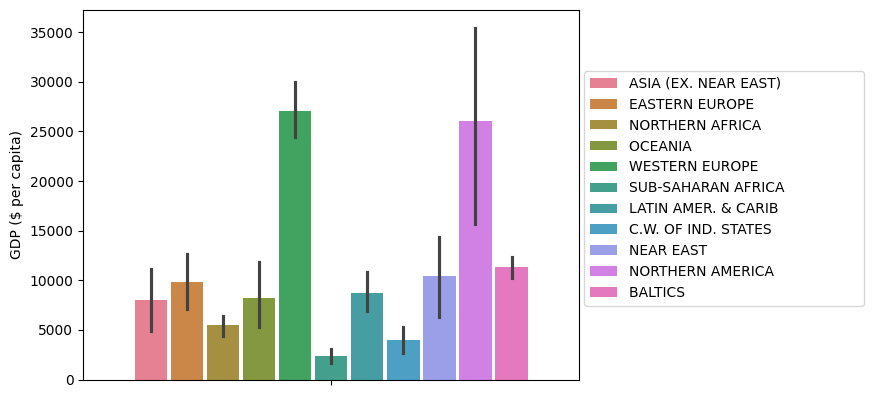

In [9]:
sns.barplot(data=df,y='GDP ($ per capita)',hue='Region',gap=0.1)
plt.legend(loc=(1.01,0.2))

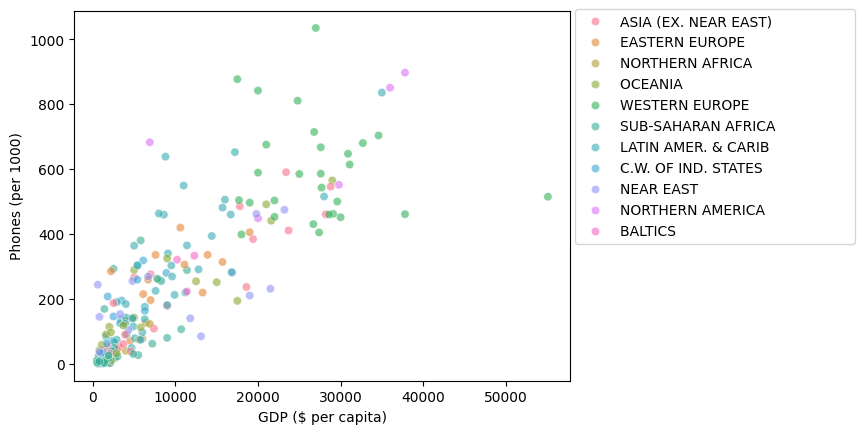

In [10]:
sns.scatterplot(data=df, x='GDP ($ per capita)',y='Phones (per 1000)',hue='Region',alpha=0.6)
plt.legend(loc=(1.01,0.37))

<Axes: xlabel='GDP ($ per capita)', ylabel='Literacy (%)'>

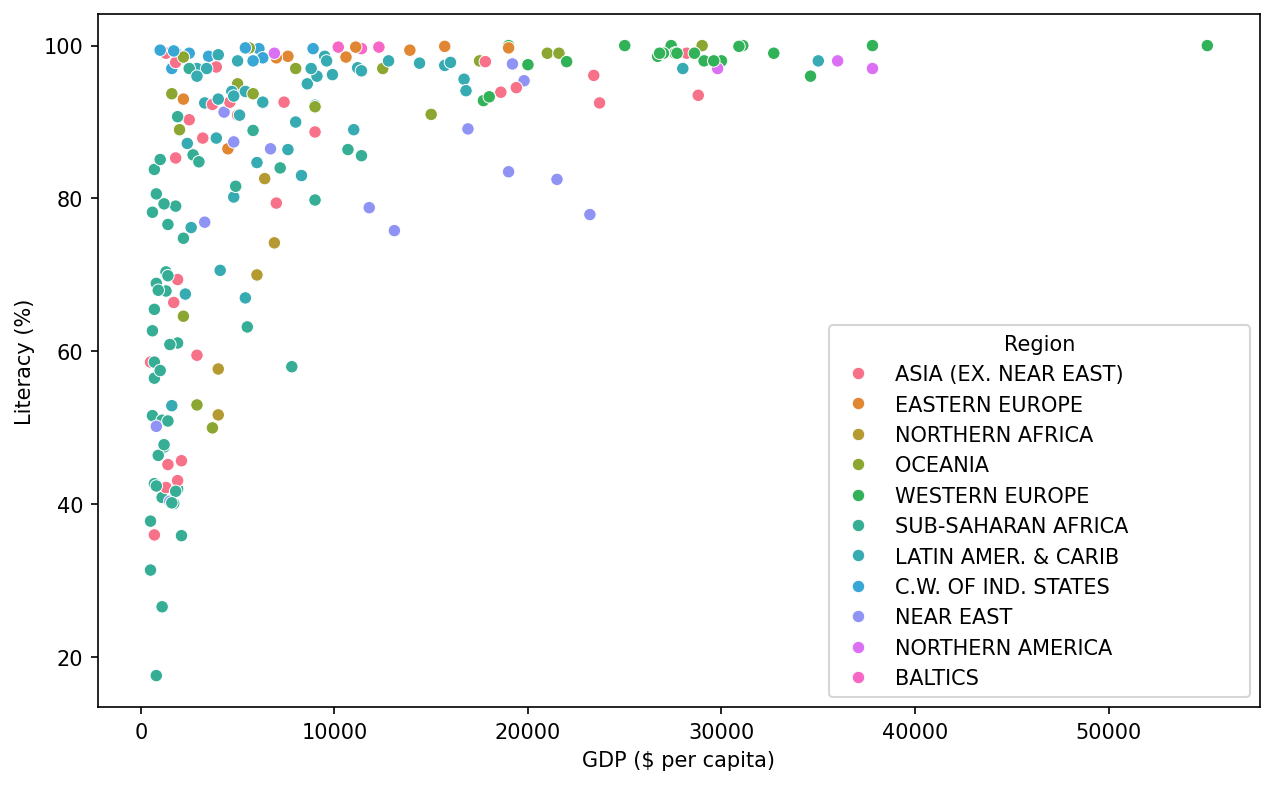

In [11]:
plt.figure(figsize=(10,6),dpi=150)
sns.scatterplot(data=df,x='GDP ($ per capita)',y='Literacy (%)',hue='Region')

**Conclusions from this plot**

There is little chance to grow GDP as far as literacy is below 90%.

<Axes: >

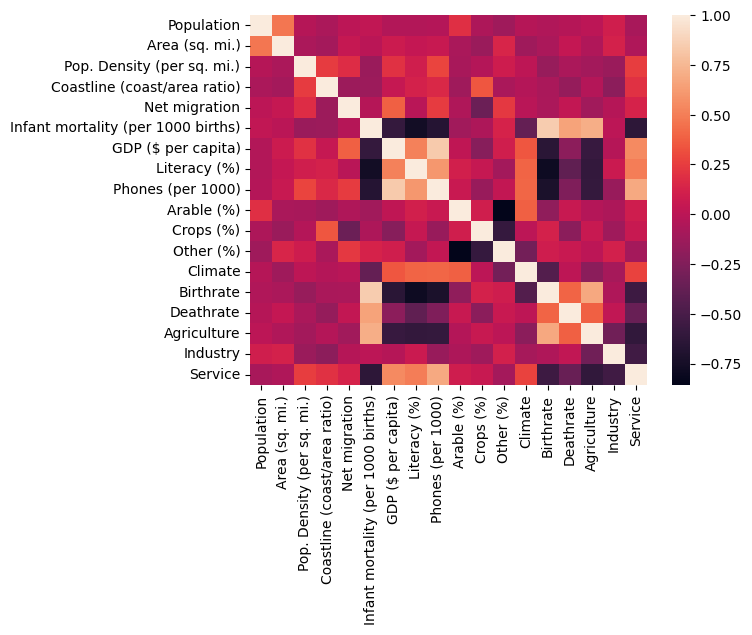

In [12]:
sns.heatmap(data=df.corr(numeric_only=True))

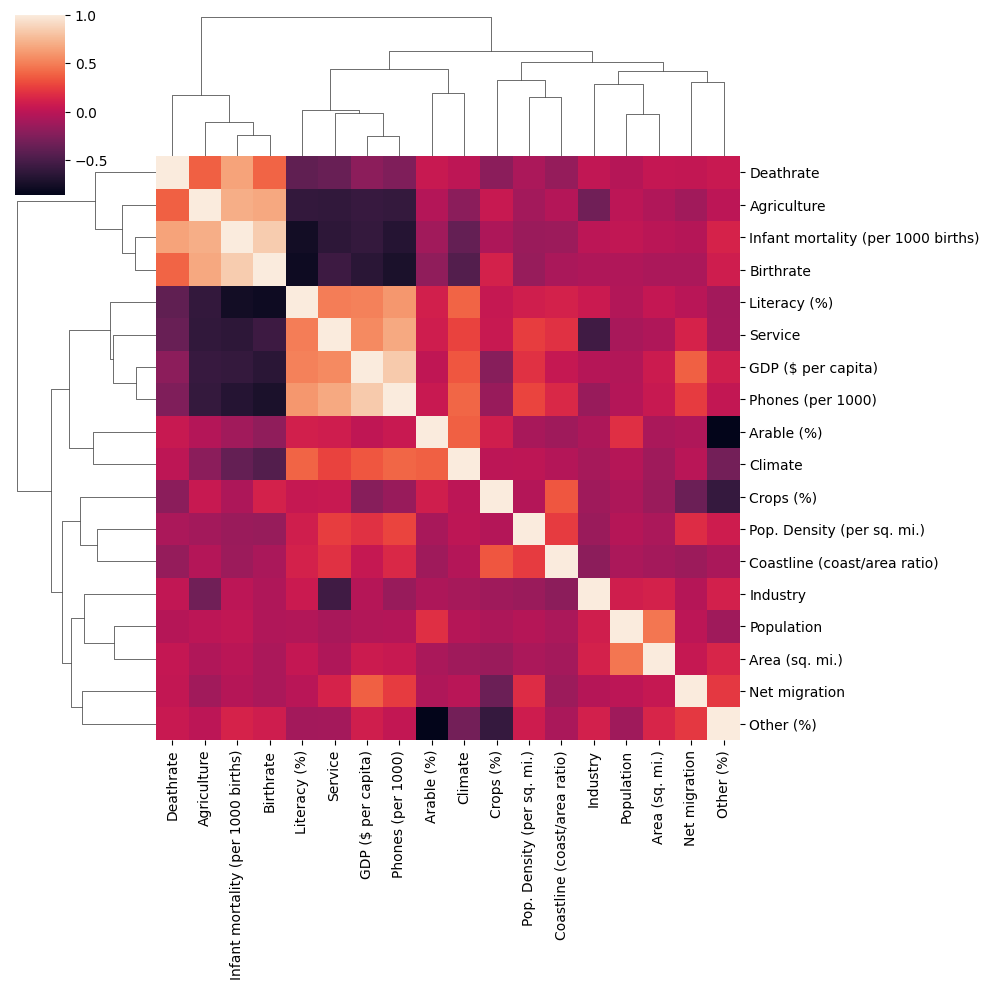

In [13]:
sns.clustermap(data=df.corr(numeric_only=True))

# Data Preparation and Model Discovery

In [14]:
# Number of nulls per column.
df.isnull().sum(axis=0)

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

In [15]:
df[df['Agriculture'].isnull()]['Country']

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: str

They are small islands or desert countries.

**Fill in with 0 any NaN values for these countries**

In [16]:
df[df['Agriculture'].isnull()]=df[df['Agriculture'].isnull()].fillna(value=0)

In [17]:
df[df['Agriculture']==0]['Country']

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
184               Singapore
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: str

In [18]:
# Remaining nuls
df.isnull().sum(axis=0)

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                               18
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**Replace NaN in Climate with the mean value for the country's region.**

In [19]:
df["Climate"]=df.groupby("Region")["Climate"].transform('mean')

In [20]:
df.isnull().sum(axis=0)

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                                0
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**Replace NaN in "Literacy" with the mean of the region**

In [21]:
df['Literacy (%)']=df.groupby("Region")['Literacy (%)'].transform('mean')

In [22]:
df.isnull().sum(axis=0)

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         1
Infant mortality (per 1000 births)    1
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     2
Arable (%)                            1
Crops (%)                             1
Other (%)                             1
Climate                               0
Birthrate                             1
Deathrate                             2
Agriculture                           0
Industry                              1
Service                               1
dtype: int64

In [23]:
df.loc[85,'Crops (%)']=0

In [24]:
df.loc[85,'Other (%)']=0

In [25]:
df.loc[85,'Arable (%)']=0

In [26]:
df.isnull().sum(axis=0)

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         1
Infant mortality (per 1000 births)    1
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     2
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Climate                               0
Birthrate                             1
Deathrate                             2
Agriculture                           0
Industry                              1
Service                               1
dtype: int64

**drop the rest of rows having any NaN**

In [27]:
df=df.dropna()

In [28]:
df.isnull().sum(axis=0)

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Climate                               0
Birthrate                             0
Deathrate                             0
Agriculture                           0
Industry                              0
Service                               0
dtype: int64

# Data feature preparation

In [29]:
X = pd.get_dummies(df.drop(['Country'], axis=1))

In [30]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Population,222.0,2.933670e+07,1.191482e+08,7026.000000,442531.750000,5.128409e+06,1.836031e+07,1.313974e+09
Area (sq. mi.),222.0,6.111922e+05,1.808296e+06,7.000000,5288.500000,9.165000e+04,4.471875e+05,1.707520e+07
Pop. Density (per sq. mi.),222.0,3.127081e+02,1.292194e+03,0.000000,28.400000,7.740000e+01,1.909750e+02,1.618300e+04
Coastline (coast/area ratio),222.0,2.044063e+01,7.198779e+01,0.000000,0.100000,7.150000e-01,1.020000e+01,8.706600e+02
Net migration,222.0,7.612613e-03,4.882836e+00,-20.990000,-0.907500,0.000000e+00,9.850000e-01,2.306000e+01
Infant mortality (per 1000 births),222.0,3.549842e+01,3.555993e+01,0.000000,8.070000,2.100000e+01,5.609500e+01,1.911900e+02
GDP ($ per capita),222.0,9.621622e+03,1.003656e+04,0.000000,1900.000000,5.550000e+03,1.552500e+04,5.510000e+04
Literacy (%),222.0,8.130034e+01,1.353320e+01,56.033333,61.284314,8.390000e+01,9.065455e+01,9.973333e+01
Phones (per 1000),222.0,2.298667e+02,2.230792e+02,0.000000,34.175000,1.589500e+02,3.839000e+02,8.980000e+02
Arable (%),222.0,1.369869e+01,1.307237e+01,0.000000,3.092500,1.040000e+01,2.000000e+01,6.211000e+01


In [31]:
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,79.553571,3.2,12.13,...,False,False,False,False,False,False,False,False,False,False
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,97.088889,71.2,21.09,...,False,False,True,False,False,False,False,False,False,False
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,56.033333,78.1,3.22,...,False,False,False,False,False,True,False,False,False,False
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,83.900000,259.5,10.00,...,False,False,False,False,False,False,False,True,False,False
4,71201,468,152.1,0.00,6.60,4.05,19000.0,94.291667,497.2,2.22,...,False,False,False,False,False,False,False,False,False,True


In [32]:
X.columns

Index(['Population', 'Area (sq. mi.)', 'Pop. Density (per sq. mi.)',
       'Coastline (coast/area ratio)', 'Net migration',
       'Infant mortality (per 1000 births)', 'GDP ($ per capita)',
       'Literacy (%)', 'Phones (per 1000)', 'Arable (%)', 'Crops (%)',
       'Other (%)', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture',
       'Industry', 'Service', 'Region_ASIA (EX. NEAR EAST)         ',
       'Region_BALTICS                            ',
       'Region_C.W. OF IND. STATES ',
       'Region_EASTERN EUROPE                     ',
       'Region_LATIN AMER. & CARIB    ',
       'Region_NEAR EAST                          ',
       'Region_NORTHERN AFRICA                    ',
       'Region_NORTHERN AMERICA                   ',
       'Region_OCEANIA                            ',
       'Region_SUB-SAHARAN AFRICA                 ',
       'Region_WESTERN EUROPE                     '],
      dtype='str')

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler=StandardScaler()

In [35]:
scaled_X=scaler.fit_transform(X)

In [36]:
from sklearn.cluster import KMeans

In [37]:
ssd=[]
for k in range(2,31):
    model=KMeans(n_clusters=k)
    model.fit(scaled_X)
    ssd.append(model.inertia_)

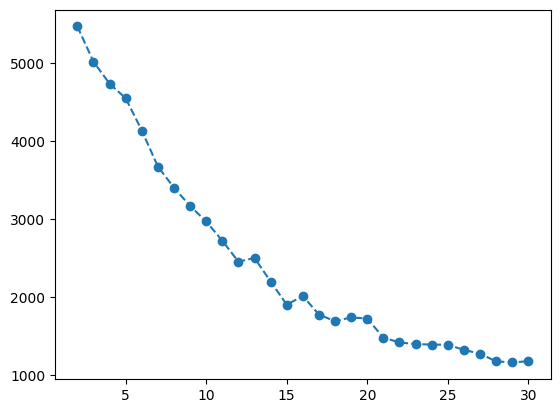

In [38]:
plt.plot(range(2,31),ssd,'o--')

<Axes: >

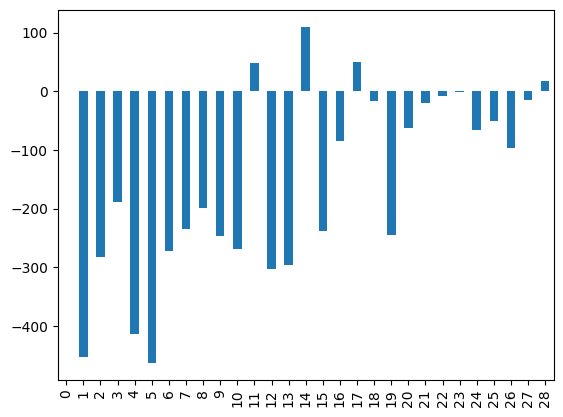

In [39]:
pd.Series(ssd).diff().plot(kind='bar')

**I think K=14 is one of the best choices**

In [40]:
model=KMeans(n_clusters=14)

In [41]:
model.fit(scaled_X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",14
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [42]:
X['K=14 Clusters']=model.labels_

In [43]:
X.corr()['K=14 Clusters'].sort_values()

Birthrate                                    -0.453352
Region_NEAR EAST                             -0.424294
Infant mortality (per 1000 births)           -0.416569
Region_ASIA (EX. NEAR EAST)                  -0.355236
Region_SUB-SAHARAN AFRICA                    -0.318376
Agriculture                                  -0.295786
Industry                                     -0.279034
Deathrate                                    -0.155575
Pop. Density (per sq. mi.)                   -0.097469
Region_EASTERN EUROPE                        -0.076068
Other (%)                                    -0.050164
Net migration                                -0.004129
Region_LATIN AMER. & CARIB                    0.002635
Crops (%)                                     0.014347
Arable (%)                                    0.039480
Region_C.W. OF IND. STATES                    0.068931
Service                                       0.123960
Region_NORTHERN AFRICA                        0.151646
Area (sq. 

In [44]:
import plotly.express as px
import plotly.io as pio

In [45]:
pio.renderers.default='notebook_connected'

In [46]:
df['Cluster']=model.labels_

In [47]:
country_iso_codes=pd.read_csv("../../jupyter_notebooks/DATA/country_iso_codes.csv")

In [48]:
country_iso_codes.head()

,Country,ISO Code
0,Afghanistan,AFG
1,"Akrotiri and Dhekelia – See United Kingdom, The","Akrotiri and Dhekelia – See United Kingdom, The"
2,Åland Islands,ALA
3,Albania,ALB
4,Algeria,DZA


In [49]:
iso_mapping=country_iso_codes.set_index('Country')['ISO Code'].to_dict()
iso_mapping

{'Afghanistan': 'AFG',
 'Akrotiri and Dhekelia – See United Kingdom, The': 'Akrotiri and Dhekelia – See United Kingdom, The',
 'Åland Islands': 'ALA',
 'Albania': 'ALB',
 'Algeria': 'DZA',
 'American Samoa': 'ASM',
 'Andorra': 'AND',
 'Angola': 'AGO',
 'Anguilla': 'AIA',
 'Antarctica\u200a[a]': 'ATA',
 'Antigua and Barbuda': 'ATG',
 'Argentina': 'ARG',
 'Armenia': 'ARM',
 'Aruba': 'ABW',
 'Ashmore and Cartier Islands – See Australia.': 'Ashmore and Cartier Islands – See Australia.',
 'Australia\u200a[b]': 'AUS',
 'Austria': 'AUT',
 'Azerbaijan': 'AZE',
 'Bahamas (the)': 'BHS',
 'Bahrain': 'BHR',
 'Bangladesh': 'BGD',
 'Barbados': 'BRB',
 'Belarus': 'BLR',
 'Belgium': 'BEL',
 'Belize': 'BLZ',
 'Benin': 'BEN',
 'Bermuda': 'BMU',
 'Bhutan': 'BTN',
 'Bolivia (Plurinational State of)': 'BOL',
 'Bonaire\xa0Sint Eustatius\xa0Saba': 'BES',
 'Bosnia and Herzegovina': 'BIH',
 'Botswana': 'BWA',
 'Bouvet Island': 'BVT',
 'Brazil': 'BRA',
 'British Indian Ocean Territory (the)': 'IOT',
 'British V

In [50]:
df['ISO_Code']=df['Country'].map(iso_mapping)
df.head(20)

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Cluster,ISO_Code
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,79.553571,...,0.22,87.65,1.962963,46.60,20.34,0.380,0.240,0.380,1,AFG
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,97.088889,...,4.42,74.49,3.111111,15.11,5.22,0.232,0.188,0.579,4,ALB
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,56.033333,...,0.25,96.53,1.500000,17.14,4.61,0.101,0.600,0.298,8,DZA
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,83.900000,...,15.00,75.00,2.000000,22.46,3.27,0.000,0.000,0.000,7,ASM
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,94.291667,...,0.00,97.78,2.826087,8.71,6.25,0.000,0.000,0.000,9,AND
5,Angola,SUB-SAHARAN AFRICA,12127071,1246700,9.7,0.13,0.00,191.19,1900.0,61.284314,...,0.24,97.35,1.846939,45.11,24.20,0.096,0.658,0.246,3,AGO
6,Anguilla,LATIN AMER. & CARIB,13477,102,132.1,59.80,10.76,21.03,8600.0,90.654545,...,0.00,100.00,2.033333,14.17,5.34,0.040,0.180,0.780,5,AIA
7,Antigua & Barbuda,LATIN AMER. & CARIB,69108,443,156.0,34.54,-6.15,19.46,11000.0,90.654545,...,4.55,77.27,2.033333,16.93,5.37,0.038,0.220,0.743,5,NaN
8,Argentina,LATIN AMER. & CARIB,39921833,2766890,14.4,0.18,0.61,15.18,11200.0,90.654545,...,0.48,87.21,2.033333,16.73,7.55,0.095,0.358,0.547,5,ARG
9,Armenia,C.W. OF IND. STATES,2976372,29800,99.9,0.00,-6.47,23.28,3500.0,98.725000,...,2.30,80.15,2.550000,12.07,8.23,0.239,0.343,0.418,6,ARM


In [51]:
df['ISO_Code'].isnull().sum()

np.int64(36)

In [52]:
df[df['ISO_Code'].isnull()].head(36)

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Cluster,ISO_Code
7,Antigua & Barbuda,LATIN AMER. & CARIB,69108,443,156.0,34.54,-6.15,19.46,11000.0,90.654545,...,4.55,77.27,2.033333,16.93,5.37,0.038,0.220,0.743,5,NaN
14,"Bahamas, The",LATIN AMER. & CARIB,303770,13940,21.8,25.41,-2.20,25.21,16700.0,90.654545,...,0.40,98.80,2.033333,17.57,9.05,0.030,0.070,0.900,5,NaN
25,Bosnia & Herzegovina,EASTERN EUROPE,4498976,51129,88.0,0.04,0.31,21.05,6100.0,97.088889,...,2.96,83.44,3.111111,8.77,8.27,0.142,0.308,0.550,4,NaN
28,British Virgin Is.,LATIN AMER. & CARIB,23098,153,151.0,52.29,10.01,18.05,16000.0,90.654545,...,6.67,73.33,2.033333,14.89,4.42,0.018,0.062,0.920,5,NaN
29,Brunei,ASIA (EX. NEAR EAST),379444,5770,65.8,2.79,3.59,12.61,18600.0,79.553571,...,0.76,98.67,1.962963,18.79,3.45,0.036,0.561,0.403,1,NaN
37,Cape Verde,SUB-SAHARAN AFRICA,420979,4033,104.4,23.93,-12.07,47.77,1400.0,61.284314,...,0.50,89.82,1.846939,24.87,6.55,0.121,0.219,0.660,3,NaN
38,Cayman Islands,LATIN AMER. & CARIB,45436,262,173.4,61.07,18.75,8.19,35000.0,90.654545,...,0.00,96.15,2.033333,12.74,4.89,0.014,0.032,0.954,9,NaN
44,Comoros,SUB-SAHARAN AFRICA,690948,2170,318.4,15.67,0.00,74.93,700.0,61.284314,...,23.32,40.81,1.846939,36.93,8.20,0.400,0.040,0.560,3,NaN
53,Czech Republic,EASTERN EUROPE,10235455,78866,129.8,0.00,0.97,3.93,15700.0,97.088889,...,3.05,57.15,3.111111,9.02,10.59,0.034,0.393,0.573,4,NaN
57,Dominican Republic,LATIN AMER. & CARIB,9183984,48730,188.5,2.64,-3.22,32.38,6000.0,90.654545,...,10.33,67.02,2.033333,23.22,5.73,0.112,0.306,0.582,5,NaN


In [53]:
df.loc[7,'ISO_Code']='ATG'

In [54]:
df.loc[14,'ISO_Code']='BHS'
df.loc[25,'ISO_Code']='BIH'
df.loc[28,'ISO_Code']='VGB'
df.loc[29,'ISO_Code']='BRN'
df.loc[37,'ISO_Code']='CPV'
df.loc[38,'ISO_Code']='CYM'

In [55]:
df.loc[44,'ISO_Code']='COM'
df.loc[53,'ISO_Code']='CZE'
df.loc[57,'ISO_Code']='DOM'
df.loc[66,'ISO_Code']='FRO'
df.loc[73,'ISO_Code']='GMB'
df.loc[122,'ISO_Code']='MAC'
df.loc[123,'ISO_Code']='MKD'
df.loc[130,'ISO_Code']='MHL'
df.loc[136,'ISO_Code']='FSM'
df.loc[137,'ISO_Code']='MDA'

In [56]:
df.loc[146,'ISO_Code']='NLD'
df.loc[153,'ISO_Code']='MNP'
df.loc[162,'ISO_Code']='PHL'
df.loc[167,'ISO_Code']='REU'
df.loc[171,'ISO_Code']='SHN'
df.loc[172,'ISO_Code']='KNA'
df.loc[174,'ISO_Code']='SPM'
df.loc[178,'ISO_Code']='STP'
df.loc[197,'ISO_Code']='SYR'

In [57]:
df.loc[198,'ISO_Code']='TWN'
df.loc[204,'ISO_Code']='TTO'
df.loc[208,'ISO_Code']='TCA'
df.loc[212,'ISO_Code']='ARE'
df.loc[220,'ISO_Code']='VIR'
df.loc[223,'ISO_Code']='ESH'

In [58]:
df[df['ISO_Code'].isnull()]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Cluster,ISO_Code
74,Gaza Strip,NEAR EAST,1428757,360,3968.8,11.11,1.60,22.93,600.0,79.521429,...,21.05,50.00,1.666667,39.45,3.80,0.030,0.283,0.687,0,NaN
147,Netherlands Antilles,LATIN AMER. & CARIB,221736,960,231.0,37.92,-0.41,10.03,11400.0,90.654545,...,0.00,90.00,2.033333,14.78,6.45,0.010,0.150,0.840,5,NaN
194,Swaziland,SUB-SAHARAN AFRICA,1136334,17363,65.5,0.00,0.00,69.27,4900.0,61.284314,...,0.70,88.95,1.846939,27.41,29.74,0.119,0.515,0.366,3,NaN
222,West Bank,NEAR EAST,2460492,5860,419.9,0.00,2.98,19.62,800.0,79.521429,...,18.97,64.13,1.666667,31.67,3.92,0.090,0.280,0.630,0,NaN


In [59]:
df=df.dropna()

In [60]:
df[df['ISO_Code'].isnull()]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Cluster,ISO_Code


In [61]:
px.choropleth(df,locations='ISO_Code',color='Cluster',hover_name='Country',basemap_visible=True)
# fig=px.choropleth(df,locations='ISO_Code',color='Cluster',hover_name='Country',basemap_visible=True)
# fig.show()